# ResNet-18 - Individual Baseline Run


In [ ]:
import sys
import os

import torch

sys.path.append(os.path.abspath("../src"))

from models import ResNet18
from data import prepare_full_dataframe, prepare_data
from train import run_training_pipeline, run_smoke_test
from utils import (
    get_device,
    print_model_overrides,
)
import config

print(f"Python:         {sys.executable}")
print(f"PyTorch:        {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
if torch.cuda.is_available():
    print(f"GPU:            {torch.cuda.get_device_name(0)}")


Python:         c:\Users\profb\PROJECTS\cxr-model-benchmark\.venv\Scripts\python.exe
PyTorch:        2.11.0+cu128
CUDA available: True
GPU:            NVIDIA GeForce RTX 5090 Laptop GPU


In [2]:
dataset_path = config.DATASET_PATH
print("Dataset location:", dataset_path)

metadata_file = os.path.join(dataset_path, "Data_Entry_2017.csv")
df = prepare_full_dataframe(metadata_file, dataset_path)

print(f"Total images:    {len(df)}")
print(f"Unique patients: {df['Patient ID'].nunique()}")

Dataset location: C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays
Total images:    112120
Unique patients: 30805


In [3]:
print(df["split"].value_counts())

split
train    78934
val      16874
test     16312
Name: count, dtype: int64


In [ ]:
train_loader, val_loader, test_loader = prepare_data(df, model_name="ResNet18")
print("Train transforms:", train_loader.dataset.transform)
device = get_device()


Using CUDA (GPU)


## Smoke Test


In [5]:
run_smoke_test(
    model_name="ResNet18",
    model_builder=lambda: ResNet18(num_classes=2, in_channels=1),
    train_loader=train_loader,
    val_loader=val_loader,
    test_loader=test_loader,
    device=device,
    live_plot=False,
)


=== Smoke test: ResNet18 (epochs=1, patience=1, batches=1) ===

=== Training ResNet18 ===

=== Run Configuration ===
Model: ResNet18
Training: epochs=1, patience=1, batch_size=256, image_size=256, seed=42
Precision/Memory: amp_enabled=True, amp_dtype=bf16, channels_last(global=True, override=None, effective=True)
Optimization: layerwise_lr_enabled=True, uses_param_groups=True, freeze_backbone_enabled=True, freeze_backbone_epochs=1, lr=0.0001, backbone_lr=5e-05, head_lr=0.0002, weight_decay=5e-05, label_smoothing=0.03
Scheduler: enabled=True, type=warmup_cosine, start_epoch=1, warmup_epochs=0, warmup_start_factor=0.4, cosine_t_max=1, min_lr=1e-06, steps_per_epoch=1
Checkpoint Resume: False
Model Overrides: {'backbone_lr': 5e-05, 'head_lr': 0.0002, 'freeze_backbone_epochs': 1}
Starting fresh training (resume disabled): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_resnet18\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last enabled
Scheduler active: type=

Train Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

  VRAM a/r/p: 0.12G(0.5%)/1.66G(6.9%)/1.23G(5.2%)


Val Epoch 1:   0%|          | 0/1 [00:00<?, ?it/s]

Epoch 1/1 | ETA (Remaining): 00:00:00 | Total ETA: 00:00:04
  Train Loss: 0.7215 | Train Acc: 0.4688
  Val Loss: 0.8754 | Val Acc: 0.4648
  Val Precision: 0.4648
  Val Recall: 1.0000 | Val F1: 0.6347
  Val AUPRC: 0.4449
  Backbone LR: 1e-06 | Head LR: 1e-06
  Optimizer: AdamW | Weight Decay: 5e-05 | No-Decay Groups: 2
------------------------------------------------------------
Saved best model to c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\models\best_resnet18.pt
------------------------------------------------------------


Test:   0%|          | 0/1 [00:00<?, ?it/s]

({'model': 'ResNet18',
  'epochs': 1,
  'batch_size': 256,
  'image_size': 256,
  'test_loss': 0.8122525215148926,
  'accuracy': 0.515625,
  'precision': 0.5176470588235295,
  'recall': 0.9924812030075187,
  'f1': 0.6804123711340206,
  'auprc': 0.555107000579395},
 {'train_loss': [0.7214595675468445],
  'train_acc': [0.46875],
  'val_loss': [0.8753742575645447],
  'val_acc': [0.46484375],
  'val_precision': [0.46484375],
  'val_recall': [1.0],
  'val_f1': [0.6346666666666667],
  'val_auprc': [0.4448631004366326],
  'lr': [1e-06],
  'lr_backbone': [1e-06],
  'lr_head': [1e-06],
  'backbone_frozen': [True],
  'vram_peak_pct': [5.152440368062422],
  'best_epoch': 1})

## Training

In [ ]:
### Function Definitions



=== Training ResNet18 ===

=== Run Configuration ===
Model: ResNet18
Training: epochs=30, patience=5, batch_size=256, image_size=256, seed=42
Precision/Memory: amp_enabled=True, amp_dtype=bf16, channels_last(global=True, override=None, effective=True)
Optimization: layerwise_lr_enabled=True, uses_param_groups=True, freeze_backbone_enabled=True, freeze_backbone_epochs=1, lr=0.0001, backbone_lr=5e-05, head_lr=0.0002, weight_decay=5e-05, label_smoothing=0.03
Scheduler: enabled=True, type=warmup_cosine, start_epoch=1, warmup_epochs=1, warmup_start_factor=0.4, cosine_t_max=29, min_lr=1e-06, steps_per_epoch=1
Checkpoint Resume: True
Model Overrides: {'backbone_lr': 5e-05, 'head_lr': 0.0002, 'freeze_backbone_epochs': 1}
Starting fresh training (checkpoint completed): c:\Users\profb\PROJECTS\cxr-model-benchmark\outputs\checkpoints\best_resnet18\latest.pt
AMP enabled (bf16, grad scaler: off)
channels_last enabled
Scheduler active: type=warmup_cosine, start_epoch=1, steps_per_epoch=1, cosine_t_

Train Epoch 1:   0%|          | 0/309 [00:14<?, ?it/s]

KeyboardInterrupt: 

run_results = []
baseline_auprc = 0.650

from notebook_experiment_runner import (
    cleanup_training_artifacts,
    print_planned_run_configuration,
    run_seed_experiment,
)


seed_bank = tuple(config.TUNING_OVERRIDES.get("ResNet18", {}).get("seed_bank", [16, 32, 64]))
epoch_log_file = "../outputs/experiment_outputs/resnet18_epoch_metrics.log"

def run_resnet_experiment(seeds=seed_bank, live_plot=True, reset_results=False, reset_epoch_log=True):
    run_seed_experiment(
        run_results=run_results,
        baseline_auprc=baseline_auprc,
        model_builder=lambda: ResNet18(num_classes=2, in_channels=1),
        train_loader=train_loader,
        val_loader=val_loader,
        test_loader=test_loader,
        device=device,
        model_name="ResNet18",
        seeds=seeds,
        live_plot=live_plot,
        reset_results=reset_results,
        epoch_log_file=epoch_log_file,
        reset_epoch_log=reset_epoch_log,
    )


In [ ]:
### Run


NameError: name 'history' is not defined

print_planned_run_configuration(
    model_name="ResNet18",
    model_builder=lambda: ResNet18(num_classes=2, in_channels=1),
    device=device,
    resume_from_checkpoint=False,
)


In [ ]:
run_resnet_experiment()



=== Test Results ===
Best Epoch:  9
Loss:        0.6267
Accuracy:    0.6668
Precision:   0.6551
Recall:      0.5890
F1:          0.6203
AUPRC:       0.6564


Val:   0%|          | 0/64 [00:00<?, ?it/s]

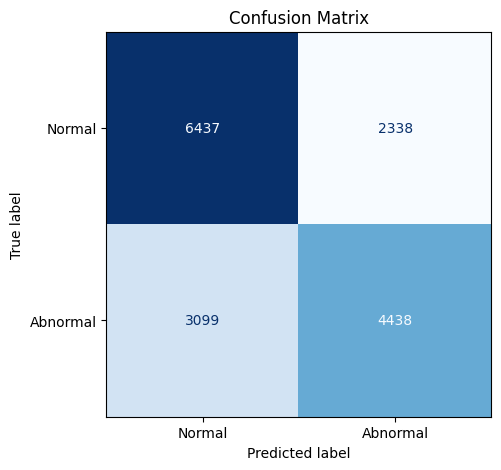

In [ ]:
## Complete Metrics


In [ ]:
import pandas as pd

summary_df = pd.DataFrame([
    {
        "Seed": r["seed"],
        "Best Epoch": r["best_epoch"],
        "Best Val AUPRC": f"{r['best_val_auprc']:.4f}" if r['best_val_auprc'] else "N/A",
        "Delta": f"{r['delta']:.4f}" if r['delta'] else "N/A",
    }
    for r in run_results
])

print("\n=== Run Comparison ===")
print(summary_df.to_string(index=False))

if len(run_results) > 1:
    valid_auprc = [r["best_val_auprc"] for r in run_results if r["best_val_auprc"] is not None]
    valid_best_epochs = [r["best_epoch"] for r in run_results if r["best_epoch"] is not None]
    mean_auprc = sum(valid_auprc) / len(valid_auprc)
    mean_delta = sum(r["delta"] for r in run_results if r["delta"] is not None) / len(valid_auprc)
    mean_best_epoch = sum(valid_best_epochs) / len(valid_best_epochs)
    std_auprc = (sum((x - mean_auprc) ** 2 for x in valid_auprc) / len(valid_auprc)) ** 0.5
    print(f"\nMean Best Epoch: {mean_best_epoch:.2f}")
    print(f"Mean Val AUPRC: {mean_auprc:.4f} ({mean_delta:+.4f})")
    print(f"Std Dev: {std_auprc:.4f}")


Image path:       C:\Users\profb\PROJECTS\datasets\NIH_Chest_X-Rays\images_007\images\00014015_015.png
True label:       abnormal
Predicted class:  abnormal
Probabilities:    {'normal': 0.36441972851753235, 'abnormal': 0.6355802416801453}
